### 라이브러리 선언

In [1]:
# 데이터처리 라이브러리
import pandas as pd
import numpy as np

# 데이터 전처리 라이버리
from sklearn.model_selection import train_test_split

In [2]:
# 딥러닝 라이브러리
import tensorflow as tf
from tensorflow import keras

In [27]:
from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [3]:
gitUrl = "https://raw.githubusercontent.com/hyokwan/python-lecture/master/dataset/feature_regression_example.csv"
featuresData = pd.read_csv(gitUrl)

# A. 데이터 전처리

### 1.타입 통합 및 숫자형 컬럼 추가

In [4]:
### 타입 통합 (테이블정의서 동일하게 데이터타입을 맞추는작업)

In [5]:
### 숫자형 컬럼 추가
ynMap = {"N":0, "Y":1}
featuresData["HOLIDAY_LE"] = featuresData.HOLIDAY.map(ynMap )
featuresData["PROMOTION_LE"] = featuresData.PROMOTION.map(ynMap )
featuresData.head(2)

,REGIONID,PRODUCTGROUP,PRODUCT,ITEM,YEARWEEK,YEAR,WEEK,QTY,HOLIDAY,HCLUS,PROMOTION,PRO_PERCENT,HOLIDAY_LE,PROMOTION_LE
0,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201501,2015,1,1225,Y,1,Y,0.209442,1,1
1,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201502,2015,2,968,N,4,Y,0.209442,0,1


In [28]:
hclustScaler = MinMaxScaler()
propercentScaler = MinMaxScaler()
promotionScaler = MinMaxScaler()
holidayScaler = MinMaxScaler()

In [34]:
featuresData["HCLUS_SCALE"] = hclustScaler.fit_transform( featuresData.loc[ :, ["HCLUS"]] )
featuresData["PROPERCENT_SCALE"] = propercentScaler.fit_transform( featuresData.loc[ :, ["PRO_PERCENT"]] )
featuresData["PROMOTION_SCALE"] = promotionScaler.fit_transform( featuresData.loc[ :, ["PROMOTION_LE"]] )
featuresData["HOLIDAY_SCALE"] = holidayScaler.fit_transform( featuresData.loc[ :, ["HOLIDAY_LE"]] )

### 2. 특성선정 및 데이터 분리

In [53]:
label = ["QTY"]

In [54]:
features = list ( featuresData.select_dtypes(np.number).columns )

In [56]:
features

['YEARWEEK',
 'YEAR',
 'WEEK',
 'QTY',
 'HCLUS',
 'PRO_PERCENT',
 'HOLIDAY_LE',
 'PROMOTION_LE',
 'HCLUS_SCALE',
 'PROPERCENT_SCALE',
 'PROMOTION_SCALE',
 'HOLIDAY_SCALE']

In [58]:
features.remove(label[0])

ValueError: list.remove(x): x not in list

In [59]:
features = ["HCLUS_SCALE","PROPERCENT_SCALE","PROMOTION_SCALE","HOLIDAY_SCALE"]

In [60]:
trainData, testData = train_test_split( featuresData, test_size=0.2, random_state=2)
trainDataFeatures = trainData.loc[ :, features]
trainDataLabel = trainData.loc[ :, label]
testDataFeatures = testData.loc[ :, features]
testDataLabel = testData.loc[ :, label]
print(trainDataFeatures.shape )
print(trainDataLabel.shape )
print(testDataFeatures.shape )
print(testDataLabel.shape )

(84, 4)
(84, 1)
(21, 4)
(21, 1)


# B. 모델 생성/훈련

### 3. 모델 생성

In [61]:
## 딥러닝 레이어를 층층으로 쌓겠다
from tensorflow.keras import Sequential
## 딥러닝 레이어중에서 : 전체연결하는 가장 기본레이어 : Dense
from tensorflow.keras.layers import Dense, Input

In [62]:
# 훈련데이터의 문제지를 활용해서 shape을 찾는다
# 인덱스로 0번째 인덱스를 찾은 후 한개행의 shape을 찾는다.
inputShape = trainDataFeatures.iloc[0].shape
inputShape

(4,)

In [63]:
unitSize = 64

In [64]:
# 모델 초기화
model = Sequential()
# #1. 인풋레이어 (input layer)
model.add( Input (shape = inputShape ) )
# #2. 히든레이어 (hidden layer)
model.add( Dense( units=unitSize, activation="relu"))
model.add( Dense( units=unitSize, activation="relu"))
# #3. 출력레이어 (output layer)
model.add( Dense( units=1, activation="relu"))

In [65]:
# 모델 초기화
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# # pyot 및 graphviz 설치 필요
# from tensorflow.keras.utils import plot_model

In [67]:
# plot_model( model, show_shapes=True)

### 4. 모델 컴파일

In [68]:
## 생성된 모델에 손실함수(loss_function) 및 최적화함수 (교수매핑: adam)
model.compile(loss="mean_squared_error",
              optimizer="adam",
              metrics=["mean_squared_error","mean_absolute_error"])

### 5. 모델 훈련

In [ ]:
fittedModel = model.fit(x=trainDataFeatures,y=trainDataLabel,batch_size=32, epochs=2000, validation_split=0.2)

Epoch 1/500


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 1962877.5000 - mean_absolute_error: 1175.7990 - mean_squared_error: 1962877.5000 - val_loss: 2096906.3750 - val_mean_absolute_error: 1145.9716 - val_mean_squared_error: 2096906.3750
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1962514.6250 - mean_absolute_error: 1175.6541 - mean_squared_error: 1962514.6250 - val_loss: 2096580.5000 - val_mean_absolute_error: 1145.8335 - val_mean_squared_error: 2096580.5000
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1962178.3750 - mean_absolute_error: 1175.5144 - mean_squared_error: 1962178.3750 - val_loss: 2096250.8750 - val_mean_absolute_error: 1145.6952 - val_mean_squared_error: 2096250.8750
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1961836.2500 - mean_absolute_error: 1175.3727 - mean_squared_error: 1961836.2500 - val_loss: 2095918.6250 - val_mean_absolute_error: 1145.5551 - val_mean_squared_error: 2095918.6250
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step -

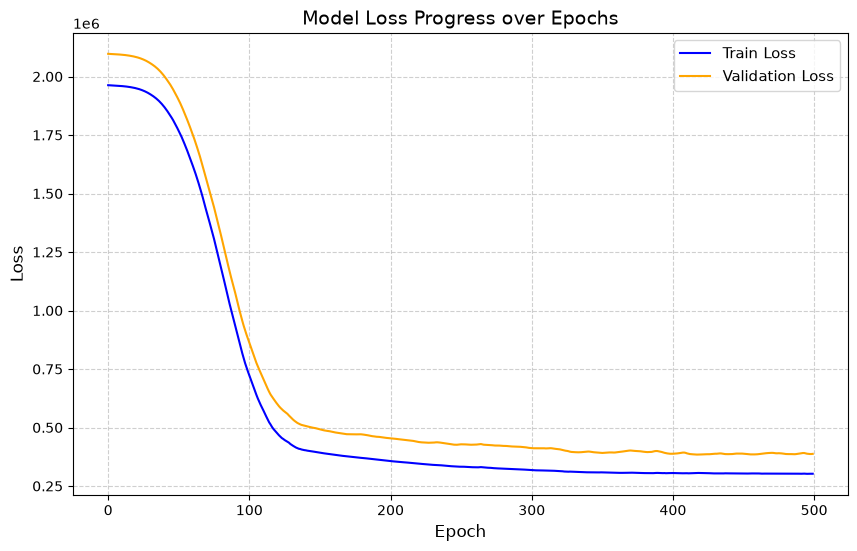

In [70]:
import matplotlib.pyplot as plt

# 차트 크기 설정
plt.figure(figsize=(10, 6))

# loss 및 val_loss 시각화
plt.plot(fittedModel.history['loss'], label='Train Loss', color='blue')
plt.plot(fittedModel.history['val_loss'], label='Validation Loss', color='orange')

# 축 및 제목 설정
plt.title('Model Loss Progress over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 차트 출력
plt.show()